# Handwritten Digit Classification using CNN and RNN
#### Project Dataset -- MNIST Digit Classification

### 1. Loading the Dataset 

##### -- Imports -- 

In [1]:
import torch 
import torch.nn as nn
import torchvision 
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307),(0.3081))
])

In [3]:
train_df = torchvision.datasets.MNIST(root = "./data",
                                train = True,
                                transform = transform,
                                download = True)

test_df = torchvision.datasets.MNIST(root = "./data", 
                                    train = False, 
                                    transform = transform, 
                                    download = True)

In [4]:
train_df

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.1307, std=0.3081)
           )

In [5]:
test_df

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.1307, std=0.3081)
           )

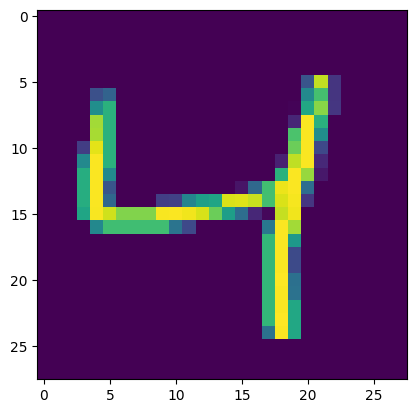

In [6]:
# image visualization 

image , label = train_df[2]
plt.imshow(image.squeeze().numpy())
plt.show()

### 2. Data Loader

In [7]:
train_loader = DataLoader(train_df,batch_size=64,shuffle=True)
test_loader = DataLoader(test_df,batch_size=64) 

## ----------------- CNN MODEL -----------------

### 3. Build our CNN model 

In [8]:
class CNN(nn.Module): 
    def __init__(self):
        super().__init__()

        self.conv_layer = nn.Sequential(
            
            nn.Conv2d(1,32,kernel_size=3,padding=1),  
            nn.ReLU(),  
            nn.MaxPool2d(2,2), 

            nn.Conv2d(32,64,kernel_size=3,padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(2,2), 

            nn.Conv2d(64,128,kernel_size=3,padding=1),  
            nn.ReLU(),  
            nn.MaxPool2d(2,2),)  


        self.fc_layer = nn.Sequential(
            nn.Linear(3*3*128,256),
            nn.ReLU(),
            nn.Linear(256,10),)

    def forward(self,x): 
        x = self.conv_layer(x) 
        x = x.view(x.size(0),-1) 
        x = self.fc_layer(x)
        return x

### 4. Training our CNN Model 

In [9]:
cnn_model = CNN() 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters()) 

In [10]:
epochs = 10
cnn_losses = []

for epoch in range(epochs): 
    epoch_training_loss = 0.0
    cnn_model.train() 

    for image , label in train_loader: 
        optimizer.zero_grad()
        
        output = cnn_model.forward(image)
        loss = criterion(output,label)
        loss.backward()
        optimizer.step()

        epoch_training_loss+= loss.item()
        cnn_losses.append(loss.item())
    
    print(f"epoch {epoch+1}/{epochs} == loss ==  {epoch_training_loss/len(train_loader)}")

epoch 1/10 == loss ==  0.13301302498302806
epoch 2/10 == loss ==  0.039683219704859905
epoch 3/10 == loss ==  0.028638302058524225
epoch 4/10 == loss ==  0.02155117892879038
epoch 5/10 == loss ==  0.018499297517310106
epoch 6/10 == loss ==  0.01422447536839436
epoch 7/10 == loss ==  0.011949229952118997
epoch 8/10 == loss ==  0.011156810628395365
epoch 9/10 == loss ==  0.009593345498767647
epoch 10/10 == loss ==  0.008517653094614365


### 5. Evaluation 

In [11]:
cnn_model.eval()

total = 0 
correct_pred = 0

with torch.no_grad(): 
    for image , label in test_loader: 
        output = cnn_model(image) 
        max, predicted = torch.max(output,1) 

        correct_pred += (predicted == label).sum().item()
        total += label.size(0)

print(total)
print(correct_pred)
accuracy = (correct_pred/total)*100
print(accuracy)

10000
9926
99.26


## ----------------- RNN MODEL -----------------

### 1. Building our RNN model 

In [12]:
class RNN(nn.Module):
    def __init__(self,input_size,hidden_size = 128,num_layer=1):  
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layer = num_layer

        # RNN layer 
        self.rnn = nn.RNN(input_size,hidden_size,num_layer,batch_first= True)

        # Fully Connected Layer 
        self.fc_layer = nn.Linear(hidden_size,10)

    def forward(self,x): 
        h0 = torch.zeros(self.num_layer,x.size(0),self.hidden_size) 

        out , _ = self.rnn(x,h0)  
        out = self.fc_layer(out[:,-1,:])
        return out 

### 2. Train Our Model 

In [13]:
input_size = 28 
rnn_model = RNN(input_size=input_size)
optimizer = optim.Adam(rnn_model.parameters())

In [15]:
epochs = 10 
rnn_losses = []
for epoch in range(epochs):
    rnn_model.train()
    epoch_loss = 0.0

    for xb , yb in train_loader:
        optimizer.zero_grad() 
        xb = xb.squeeze(1)
        
        output = rnn_model(xb)
        loss = criterion(output,yb) 
        
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        rnn_losses.append(loss.item())

    print(f"epoch = {epoch+1}/{epochs} & loss = {epoch_loss/len(train_loader)}")

epoch = 1/10 & loss = 0.6736667606272677
epoch = 2/10 & loss = 0.28572460406148104
epoch = 3/10 & loss = 0.21700794833190024
epoch = 4/10 & loss = 0.18571886422632855
epoch = 5/10 & loss = 0.16546818410266817
epoch = 6/10 & loss = 0.14883806004818442
epoch = 7/10 & loss = 0.13470038944787815
epoch = 8/10 & loss = 0.13580465156024993
epoch = 9/10 & loss = 0.12851685294950965
epoch = 10/10 & loss = 0.1192055280540766


### 3. Evaluation 

In [16]:
rnn_model.eval() 
with torch.no_grad():
    correct = 0 
    total_ = 0 
    
    for image,label in test_loader:
        image = image.squeeze(1)
        output = rnn_model(image)
        max , predicted = torch.max(output,1)
        total_ += label.size(0)
        correct += (predicted == label).sum().item()

print(total_)
print(correct)
rnn_accuracy = (correct/total_)*100
print(rnn_accuracy)

10000
9434
94.34


## Comapring Both CNN and RNN 

In [19]:
import pandas as pd 
compare = pd.DataFrame({
    "Model": ["CNN", "RNN"],
    "Accuracy": [accuracy, rnn_accuracy]
})

compare

,Model,Accuracy
0,CNN,99.26
1,RNN,94.34


## Saving The Result

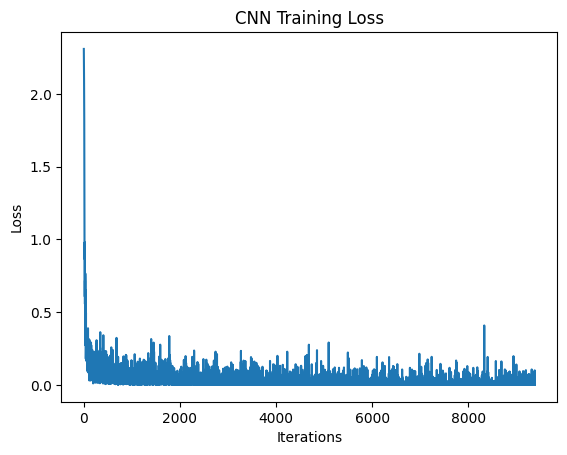

In [20]:
# CNN RESULT---
plt.plot(cnn_losses)
plt.title("CNN Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.savefig("../results/cnn_loss.png")
plt.show()

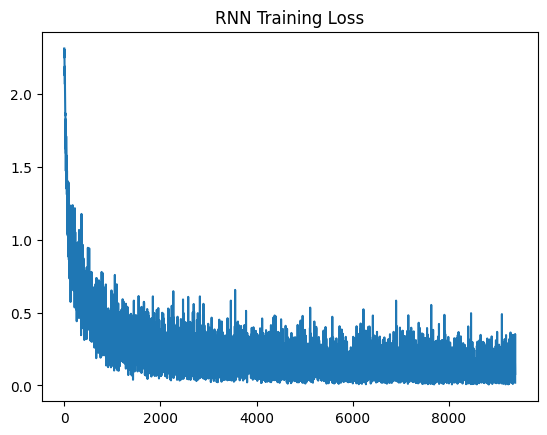

In [21]:
# RNN RESULT
plt.plot(rnn_losses)
plt.title("RNN Training Loss")
plt.savefig("../results/rnn_loss.png")
plt.show()

The CNN model achieved higher accuracy than the RNN model.
This is expected because CNNs capture spatial features of images more effectively, 
while RNNs process the image sequentially.